**PARTICULA SOMETIDA A UN CAMPO ELECTRICO -$\alpha$ EN UN POZO DE POTENCIAL INFINITO**



La ecuación de Schrödinger en 1D es $-\frac{\hbar^2}{2m} \frac{d^2 \psi}{dx^2} + q\epsilon\psi = E \psi$.

In [102]:
# Tensorflow Keras and rest of the packages
import tensorflow as tf
import keras as keras
from tensorflow.keras import models,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint
import scipy
from scipy.special import airy

In [103]:
def nn_model(activation,neurons_layer,n_layers):
    input=Input(shape=(neurons_layer[0],))
    x=input
    for hidden_layer_neurons in neurons_layer[1:-1]: 
        x=Dense(hidden_layer_neurons,activation=activation)(x)
    output=Dense(neurons_layer[n_layers-1])(x)
    return input,output

In [104]:
@keras.saving.register_keras_serializable()#Esto hace que se pueda guardar el modelo y cargarlo sin problemas despues
class EVE_PINN(tf.keras.Model):# Esta clase va a heredar de la clase Model de Keras, lo que nos permite usar todos los metodos de la clase Model y ademas definir nuestros propios metodos
    def set_step_dx(self,dx): #Este metodo inicializa la clase
      self.dx=dx #Lo que hace esto es que al objeto que luego instanciamos le asigna el atributo dx, que va a ser espaciado entre puntos
    
    def parameters(self,eps,m,q):
        self.eps=eps
        self.m=m
        self.q=q

    def train_step(self, data):#Metodo que tiene internamente la clase Model del API de Keras
        x, y_exact = data

        # Use only for run_eagerly=True
        #pi = tf.constant(np.pi)
        #M0 = tf.square(pi)

        #Change initial conditions for the PINN
        x0 = tf.constant([0.0], dtype=tf.float32)
        xL = tf.constant([1.0], dtype=tf.float32) # We consider L=1
        y0_exact = tf.constant([0.0], dtype=tf.float32)
        yL_exact = tf.constant([0.0], dtype=tf.float32)
        xi = tf.reshape(x,(x.shape[0],1))#Reconversion del batch de entrada a un vector columna, para que sea coherente con la salida en columna que devuelve self(xi)
        unit = tf.constant(1.0, dtype=tf.float32)
        unit = tf.reshape(unit,shape=xi[0].shape)

        #Initializing to zero the residuo of the DE
        lossDE = tf.constant(0.0, dtype=tf.float32)

        #Initializing to zero the M function
        M = tf.constant(0.0, dtype=tf.float32)

        # Spatial mesh
        dx = tf.constant(self.dx,dtype=tf.float32)

        with tf.GradientTape() as tape:

            # Calculate the second derivative dy2/dx2
            with tf.GradientTape() as tape1:
                tape1.watch(xi)
                with tf.GradientTape() as tape2:
                    tape2.watch(xi)#Watch le dice en que tensor se tiene que fijar para los calculos, aqui le decimos que mire el batch de entrada porque luego lo utilizamos para calcular la salida, esto es asi porque tape solo se fija en tensores variables y xi es constante 
                    y_NN = xi*(unit-xi)*self(xi,training=False)#Cálculo de la y_NN para todos los datos, self(xi) hace el paso hacia delante del batch de entrada, y multplicamos por x*(1-x) para asegurar que la salida cumple las condiciones de contorno. Training=false porque esto solo sirve para calcular la funcion de perdida, es decir, estamos haciendo un predict de los datos xi de entrada
                    print(y_NN.shape)#Esto devolvera cual es el tamaño de la salida, que sera de otro vector columna, cada elemento la salida de cada dato de entrada del batch
                    tape2.watch(y_NN)#Ahora que esta calculada la salida, nos fijamos en el tensor de salida, de forma que ya podremos hacer la derivada
                dy_dx_NN = tape2.gradient(y_NN, xi)#Calcula la derivada de la salida respecto a la entrada, nos devolvera otro vector
                tape1.watch(y_NN)#De nuevo, se tiene que fijar
                tape1.watch(dy_dx_NN)#...
            d2y_dx2_NN = tf.squeeze(tape1.gradient(dy_dx_NN, xi))#Segunda derivada
            y_NN = tf.squeeze(y_NN)#Squeeze elimina las dimensiones de tamaño a 1 en los tensores, osea si tenemos un vector que seria un tensor de shape(y,1) al hacer squeeze pasa a ser solo de shape(y,), que es un vector fila 
            xi=tf.squeeze(xi)
            tape.watch(xi)
            tape.watch(y_NN)
            tape.watch(dy_dx_NN)
            tape.watch(d2y_dx2_NN)

            
            S_y_NN=-d2y_dx2_NN/(2*self.m)+y_NN*xi*self.eps*q
            num = tf.reduce_sum(y_NN*S_y_NN)#Esto es el producto escalar de y con la segunda derivada de y, no se multiplica por dx porque se va a ir luego al ser un cociente num/den
            den = tf.reduce_sum(tf.square(y_NN)) # Could this be zero? #Norma al cuadrado de y
            M = num/den #Funcion que cuando sea minima coincida con el autoestado fundamental
            M = tf.reshape(M,shape=xi[0].shape)#Reconvertimos en tensor de tamaño 0 porque era un esacalar, a un tensor de tamaño, que solo tiene un elemento que es el escalar.

            I = tf.reduce_sum(tf.square(y_NN))*dx
            I = tf.reshape(I,shape=xi[0].shape)# tensor que es la morma al cuadrado multiplicada por el factor dx de discretizacion, tambien es de dimension 1 con el reshape

            #big = tf.constant(1.0, dtype=tf.float32)
            #big = tf.reshape(big,shape=xi[0].shape)#Se crea un tensor con todos 1 de una dimension, osea un uno

            #Loss= ODE+ boundary/initial conditions
            lossDE = self.compiled_loss(S_y_NN, M*y_NN) #Esta loss lo que tiene interesante es que self.compiled_loss va a recibir como primer argumento el valor real bueno, y como segundo al valor predicho. Luego, cuando llamamos al metodo compile y le pasamos que tipo de metrica queremos, hara cuentas con ello
            loss = tf.squeeze(M + (I-unit)**2)# Esta loss es el autovalor mas la condicion de normalizacion, esta es con la que entrenamos

        gradients = tape.gradient(loss, self.trainable_weights)#Calcula la derivada de la funcion de perdida respecto a los parametros entrenables
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))#Zip empareja cada derivada de la lista gradientes con el parametro respecto al que se ha derivad0, de forma que le pasamos este tensor al optimizador que aplicara los gradientes y actualiza los parametros
        self.compiled_metrics.update_state(y_exact, y_NN)#Por ultimo, se actualiza el estado respecto al paso anterior con la y_NN calculada en este nuevo paso con los parametros anteriores
        metrics = {m.name: m.result() for m in self.metrics}#Dado que entiendo que el metodo self.compiled_metrics.updatestate actualiza las metricas como atributo del objeto en self.metrics. {} Crea un diccionario, en el que el formato_:_ indica clave:valor asociado 
        metrics['DE']=lossDE
        metrics['loss']=loss
        metrics['I']=I
        metrics['E']=M
        return metrics#Este diccionario creado que devuelve el metodo traning_step es el que utiliza model.fit para calcular las metricas

In [105]:
## Custom metric
@keras.saving.register_keras_serializable()#La serializamos para que despues al cargar el modelo, no tengamos que haber definido previamente la funcion, simplemente la habra guardado ya.
def mse_odd_even_sol(y_true, y_pred):
    return tf.minimum(tf.reduce_mean(tf.square(y_pred - y_true)),tf.reduce_mean(tf.square(y_pred + y_true)))#Devuelve el minimo entre y_NN con +-y_real 

In [106]:
# Build the model
checkpoint_callback = ModelCheckpoint(
    filepath=f"variacional_Campo_E_fundamental.weights.h5",
    monitor="loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1,
)#Esto hace que cuando se lo pasemos a model.fit nos guarde solo los parametros del modelo en variacional_E_fundamental.h5 siempre que la perdida sea menor que en la anterior epoca

dx= 0.002
      converged: True
           flag: converged
 function_calls: 41
     iterations: 39
           root: 10.368507161836533
         method: bisect
x(0)= 0.001
y(0)= 3.4638242249419736e-16


Model: "eve_pinn_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

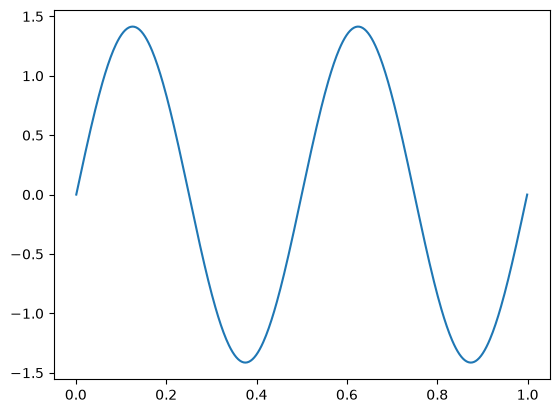

In [107]:
n_train = 500  # 500 for Sergio's estimation, 10 for Javi's
# Avoid the boundaries: ¿derivaties ill-defined at the boundaries?
xmin = 0.0 + (1.0-0.0)/(2*n_train)#xmin que no es cero, es cero mas un delta
xmax = 0.0 + (1.0-0.0)/(2*n_train) + (n_train-1)*(1.0-0.0)/n_train  #1 menos ese mismo delta, es decir, 1-xmin
# Definition of the function domain
x_train,step_dx = np.linspace(xmin,xmax,n_train,retstep=True)#No se coge ni el cero ni el uno porque los hemos forzad a ser cero al multiplicar por x*(1-x) a la yNN
print("dx=",step_dx)

#Physic's parameters
m=1/2
q=1
eps=1
alpha=np.pow(2*m*q*eps,1/3)

# The solution y(x) for training and validation datasets

def determinante(E):
    z0=-alpha*(E/eps)
    zL=alpha*(1-E/eps)
    Ai0,_,Bi0,_=airy(z0)
    AiL,_,BiL,_=airy(zL)
    det=Ai0*BiL-AiL*Bi0
    return det
#print(determinante(4), determinante (7))
E=scipy.optimize.root_scalar(determinante,bracket=[10,11],method='bisect')
print(E)
#Cte de integracion
z=alpha*(x_train-E.root/eps)
Ai,_,Bi,_=airy(z)
I=tf.reduce_sum((Ai-Ai[0]/Bi[0]*Bi)**2)*step_dx
C=1/np.sqrt(I)
y_train_fund=C*(Ai-Ai[0]/Bi[0]*Bi)
plt.plot(x_train,y_train)

print("x(0)=",x_train[0])
print("y(0)=",y_train[0])

# Input and output neurons (from the data)
neurons_layer=[1, 50, 50, 50,1]
n_layers=5


# Define the model
activation = 'tanh'
input,output = nn_model(activation,neurons_layer,n_layers)

model = EVE_PINN(input,output)
model.set_step_dx(step_dx)
model.parameters(eps,m,q)

#Define the metrics, optimizer and loss
metrics = [mse_odd_even_sol] #tf.keras.metrics.MeanSquaredError()
lr=0.01
optimizer = Adam(learning_rate=lr)

model.compile(loss='mse',
          optimizer=optimizer,
          metrics=metrics, run_eagerly=False)


# Just use `fit` as usual
#callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            #patience=5000,
                                            #restore_best_weights=True)
model.summary()

In [108]:
epochs = 2000 # 5000        
history = model.fit(x_train, y_train_fund, batch_size=n_train, epochs=epochs,
                  callbacks=[checkpoint_callback])#Evidentemente sin validacion, tamaño del batch=n_train, cada batch es una epoca 

name='Estado_fundamental_Campo_copia-1.keras'
model.save(name)

Epoch 1/2000


(500, 1)


c:\Users\ruben\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:696: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
c:\Users\ruben\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:671: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


(500, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - DE: 0.0063 - E: 15.3873 - I: 2.1948e-05 - mse_odd_even_sol: 0.9914 - loss: 16.3872
Epoch 1: loss improved from None to 16.38721, saving model to variacional_Campo_E_fundamental.weights.h5

Epoch 1: finished saving model to variacional_Campo_E_fundamental.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - DE: 0.0063 - E: 15.3873 - I: 2.1948e-05 - mse_odd_even_sol: 0.9914 - loss: 16.3872
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - DE: 4.5425 - E: 12.6521 - I: 0.0367 - mse_odd_even_sol: 0.6671 - loss: 13.5801
Epoch 2: loss improved from 16.38721 to 13.58006, saving model to variacional_Campo_E_fundamental.weights.h5

Epoch 2: finished saving model to variacional_Campo_E_fundamental.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - DE: 4.5425 - E: 12.6521 - I: 0.0367 - mse_odd_even_sol: 0.6671 - loss: 13.5801
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - DE: 10.4794 - E: 12.4003 - I: 0.0959 - mse_odd_even_sol: 0.4959 - loss: 13

In [68]:
loss_true=np.array(history.history['mse_odd_even_sol'])
eigen_value=np.array(history.history['loss'])
x=np.linspace(0,1,n_train)
print(np.shape(loss_true),np.shape(physics_loss))
#print(eigen_value)
print(loss_true)

(2000,) (2000,)
[9.91253197e-01 7.82116115e-01 7.36516058e-01 ... 1.03835373e-05
 1.03831871e-05 1.03830798e-05]


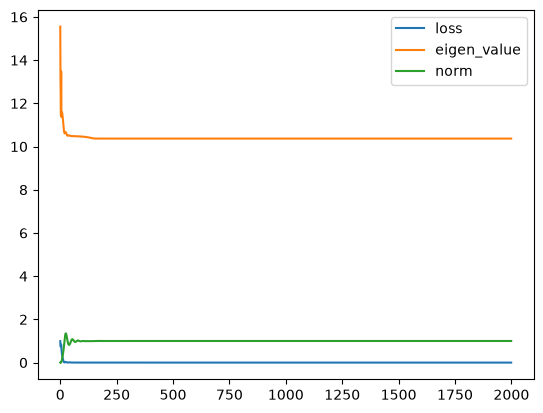

In [70]:
plt.plot(loss_true,label='loss')
plt.plot(eigen_value,label='eigen_value')
plt.plot(history.history['I'],label= 'norm')
#plt.yscale("log")
plt.legend()
plt.show()

In [ ]:
#model=keras.models.clone_model(name)
#set_weights(get_weights())
n_points=1000
x=np.linspace(-2,2,n_train)
y_NN=model.predict(x)
y_NN=np.reshape(y_NN,n_train)
factor=x-x**2
y=y_NN*factor

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


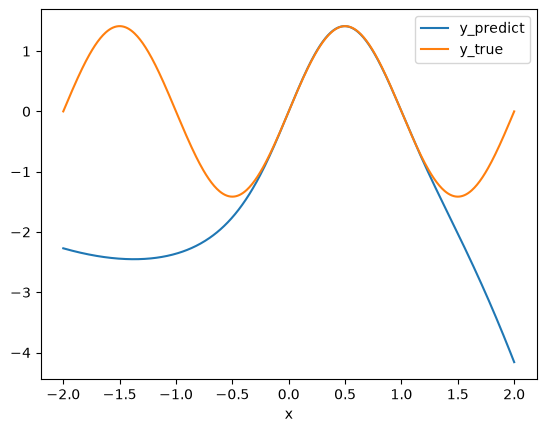

In [ ]:
plt.plot(x,y,label='y_predict')
plt.plot(x,y_train_fund,label='y_true')
plt.xlabel('x')
plt.legend()

**FIRST_EXCITED**

In [91]:
@keras.saving.register_keras_serializable()#Esto hace que se pueda guardar el modelo y cargarlo sin problemas despues
class EVE_PINN(tf.keras.Model):# Esta clase va a heredar de la clase Model de Keras, lo que nos permite usar todos los metodos de la clase Model y ademas definir nuestros propios metodos
    def fi_0(self,fi_0):
        self.fi_0=fi_0
        
    def set_step_dx(self,dx): #Este metodo inicializa la clase
      self.dx=dx #Lo que hace esto es que al objeto que luego instanciamos le asigna el atributo dx, que va a ser espaciado entre puntos
    
    def parameters(self,eps,m,q):
        self.eps=eps
        self.m=m
        self.q=q

    def train_step(self, data):#Metodo que tiene internamente la clase Model del API de Keras
        x, y_exact = data

        # Use only for run_eagerly=True
        #pi = tf.constant(np.pi)
        #M0 = tf.square(pi)

        #Change initial conditions for the PINN
        x0 = tf.constant([0.0], dtype=tf.float32)
        xL = tf.constant([1.0], dtype=tf.float32) # We consider L=1
        y0_exact = tf.constant([0.0], dtype=tf.float32)
        yL_exact = tf.constant([0.0], dtype=tf.float32)
        xi = tf.reshape(x,(x.shape[0],1))#Reconversion del batch de entrada a un vector columna, para que sea coherente con la salida en columna que devuelve self(xi)
        unit = tf.constant(1.0, dtype=tf.float32)
        unit = tf.reshape(unit,shape=xi[0].shape)
        #Converting the dtype of fi_0 to float32
        fi_0=tf.constant(self.fi_0,dtype=tf.float32)
        print(fi_0.shape)
        #Initializing to zero the residuo of the DE
        lossDE = tf.constant(0.0, dtype=tf.float32)

        #Initializing to zero the M function
        M = tf.constant(0.0, dtype=tf.float32)

        # Spatial mesh
        dx = tf.constant(self.dx,dtype=tf.float32)

        with tf.GradientTape() as tape:

            # Calculate the second derivative dy2/dx2
            with tf.GradientTape() as tape1:
                tape1.watch(xi)
                with tf.GradientTape() as tape2:
                    tape2.watch(xi)#Watch le dice en que tensor se tiene que fijar para los calculos, aqui le decimos que mire el batch de entrada porque luego lo utilizamos para calcular la salida, esto es asi porque tape solo se fija en tensores variables y xi es constante 
                    y_NN = xi*(unit-xi)*self(xi,training=False)#Cálculo de la y_NN para todos los datos, self(xi) hace el paso hacia delante del batch de entrada, y multplicamos por x*(1-x) para asegurar que la salida cumple las condiciones de contorno. Training=false porque esto solo sirve para calcular la funcion de perdida, es decir, estamos haciendo un predict de los datos xi de entrada
                    print(y_NN.shape)#Esto devolvera cual es el tamaño de la salida, que sera de otro vector columna, cada elemento la salida de cada dato de entrada del batch
                    tape2.watch(y_NN)#Ahora que esta calculada la salida, nos fijamos en el tensor de salida, de forma que ya podremos hacer la derivada
                dy_dx_NN = tape2.gradient(y_NN, xi)#Calcula la derivada de la salida respecto a la entrada, nos devolvera otro vector
                tape1.watch(y_NN)#De nuevo, se tiene que fijar
                tape1.watch(dy_dx_NN)#...
            d2y_dx2_NN = tf.squeeze(tape1.gradient(dy_dx_NN, xi))#Segunda derivada
            y_NN = tf.squeeze(y_NN)#Squeeze elimina las dimensiones de tamaño a 1 en los tensores, osea si tenemos un vector que seria un tensor de shape(y,1) al hacer squeeze pasa a ser solo de shape(y,), que es un vector fila 
            xi=tf.squeeze(xi)
            tape.watch(xi)
            tape.watch(y_NN)
            tape.watch(dy_dx_NN)
            tape.watch(d2y_dx2_NN)

            
            S_y_NN=-d2y_dx2_NN/(2*self.m)+y_NN*xi*self.eps*q
            num = tf.reduce_sum(y_NN*S_y_NN)#Esto es el producto escalar de y con la segunda derivada de y, no se multiplica por dx porque se va a ir luego al ser un cociente num/den
            den = tf.reduce_sum(tf.square(y_NN)) # Could this be zero? #Norma al cuadrado de y
            M = num/den #Funcion que cuando sea minima coincida con el autoestado fundamental
            M = tf.reshape(M,shape=xi[0].shape)#Reconvertimos en tensor de tamaño 0 porque era un esacalar, a un tensor de tamaño, que solo tiene un elemento que es el escalar.

            I = tf.reduce_sum(tf.square(y_NN))*dx
            I = tf.reshape(I,shape=xi[0].shape)# tensor que es la morma al cuadrado multiplicada por el factor dx de discretizacion, tambien es de dimension 1 con el reshape

            #big = tf.constant(1.0, dtype=tf.float32)
            #big = tf.reshape(big,shape=xi[0].shape)#Se crea un tensor con todos 1 de una dimension, osea un uno
            
            H = tf.constant(100.0,dtype=tf.float32)
            num_1=H*(tf.reduce_sum(y_NN*fi_0)**2)
            den_1=tf.reduce_sum(tf.square(y_NN))*tf.reduce_sum(tf.square(fi_0))
            Schwartz=num_1/den_1
            Schwartz=tf.reshape(Schwartz,shape=xi[0].shape)

            #Loss= ODE+ boundary/initial conditions
            lossDE = self.compiled_loss(S_y_NN, M*y_NN) #Esta loss lo que tiene interesante es que self.compiled_loss va a recibir como primer argumento el valor real bueno, y como segundo al valor predicho. Luego, cuando llamamos al metodo compile y le pasamos que tipo de metrica queremos, hara cuentas con ello
            loss = tf.squeeze(M + (I-unit)**2+Schwartz)# Esta loss es el autovalor mas la condicion de normalizacion, esta es con la que entrenamos

        gradients = tape.gradient(loss, self.trainable_weights)#Calcula la derivada de la funcion de perdida respecto a los parametros entrenables
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))#Zip empareja cada derivada de la lista gradientes con el parametro respecto al que se ha derivad0, de forma que le pasamos este tensor al optimizador que aplicara los gradientes y actualiza los parametros
        self.compiled_metrics.update_state(y_exact, y_NN)#Por ultimo, se actualiza el estado respecto al paso anterior con la y_NN calculada en este nuevo paso con los parametros anteriores
        metrics = {m.name: m.result() for m in self.metrics}#Dado que entiendo que el metodo self.compiled_metrics.updatestate actualiza las metricas como atributo del objeto en self.metrics. {} Crea un diccionario, en el que el formato_:_ indica clave:valor asociado 
        metrics['DE']=lossDE
        metrics['loss']=loss
        metrics['I']=I
        metrics['E']=M
        return metrics#Este diccionario creado que devuelve el metodo traning_step es el que utiliza model.fit para calcular las metricas

In [92]:
# Build the model
checkpoint_callback = ModelCheckpoint(
    filepath=f"variacional_Campo_E_excited.weights.h5",
    monitor="loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1,
)#Esto hace que cuando se lo pasemos a model.fit nos guarde solo los parametros del modelo en variacional_E_fundamental.h5 siempre que la perdida sea menor que en la anterior epoca

dx= 0.002
      converged: True
           flag: converged
 function_calls: 46
     iterations: 44
           root: 39.97874478988365
         method: bisect
x(0)= 0.001
y(0)= 0.0
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


Model: "eve_pinn_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

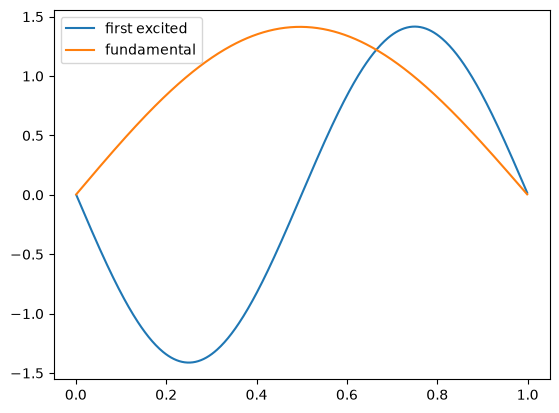

In [95]:
n_train = 500  # 500 for Sergio's estimation, 10 for Javi's
# Avoid the boundaries: ¿derivaties ill-defined at the boundaries?
xmin = 0.0 + (1.0-0.0)/(2*n_train)#xmin que no es cero, es cero mas un delta
xmax = 0.0 + (1.0-0.0)/(2*n_train) + (n_train-1)*(1.0-0.0)/n_train  #1 menos ese mismo delta, es decir, 1-xmin
# Definition of the function domain
x_train,step_dx = np.linspace(xmin,xmax,n_train,retstep=True)#No se coge ni el cero ni el uno porque los hemos forzado a ser cero al multiplicar por x*(1-x) a la yNN
print("dx=",step_dx)

#Physic's parameters
m=1/2
q=1
eps=1
alpha=np.pow(2*m*q*eps,1/3)

# The solution y(x) for training and validation datasets

def determinante(E):
    z0=-alpha*(E/eps)
    zL=alpha*(1-E/eps)
    Ai0,_,Bi0,_=airy(z0)
    AiL,_,BiL,_=airy(zL)
    det=Ai0*BiL-AiL*Bi0
    return det
#print(determinante(4), determinante (7))
E=scipy.optimize.root_scalar(determinante,bracket=[20,40],method='bisect')
print(E)
#Cte de integracion
z=alpha*(x_train-E.root/eps)
Ai,_,Bi,_=airy(z)
I=tf.reduce_sum((Ai-Ai[0]/Bi[0]*Bi)**2)*step_dx
C=1/np.sqrt(I)
y_train=C*(Ai-Ai[0]/Bi[0]*Bi)
plt.plot(x_train,y_train,label='first excited')

print("x(0)=",x_train[0])
print("y(0)=",y_train[0])

# Input and output neurons (from the data)
neurons_layer=[1, 50, 50, 50,1]
n_layers=5

#load model fundamental state
name='Estado_fundamental_Campo_copia-1.keras'
fund_model_Campo=keras.models.load_model(name)
y_NN_0=fund_model_Campo.predict(x_train)
y_NN_0=np.reshape(y_NN_0,n_train)
fi_0=y_NN_0*x_train*(1-x_train)
plt.plot(x_train, fi_0,label='fundamental')
plt.legend()

# Define the model
activation = 'tanh'
input,output = nn_model(activation,neurons_layer,n_layers)
model = EVE_PINN(input,output)
model.set_step_dx(step_dx)
model.fi_0(fi_0)
model.parameters(eps,m,q)

#Define the metrics, optimizer and loss
metrics = [mse_odd_even_sol] #tf.keras.metrics.MeanSquaredError()
lr=0.01
optimizer = Adam(learning_rate=lr)

model.compile(loss='mse',
          optimizer=optimizer,
          metrics=metrics, run_eagerly=False)


# Just use `fit` as usual
#callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            #patience=5000,
                                            #restore_best_weights=True)
model.summary()

In [96]:
epochs = 2000 # 5000        
history = model.fit(x_train, y_train, batch_size=n_train, epochs=epochs,
                  callbacks=[checkpoint_callback])#Evidentemente sin validacion, tamaño del batch=n_train, cada batch es una epoca 

name='Estado_excitado_Campo_copia-1.keras'
model.save(name)

Epoch 1/2000


(500,)
(500, 1)


c:\Users\ruben\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:696: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
c:\Users\ruben\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:671: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


(500,)
(500, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - DE: 0.0470 - E: 13.8184 - I: 2.7734e-04 - mse_odd_even_sol: 0.9895 - loss: 72.7836
Epoch 1: loss improved from None to 72.78362, saving model to variacional_Campo_E_excited.weights.h5

Epoch 1: finished saving model to variacional_Campo_E_excited.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - DE: 0.0470 - E: 13.8184 - I: 2.7734e-04 - mse_odd_even_sol: 0.9895 - loss: 72.7836
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - DE: 1.6251 - E: 12.4705 - I: 0.0137 - mse_odd_even_sol: 0.9562 - loss: 78.2304
Epoch 2: loss did not improve from 72.78362
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - DE: 1.6251 - E: 12.4705 - I: 0.0137 - mse_odd_even_sol: 0.9562 - loss: 78.2304
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - DE: 8.7903 - E: 12.7900 - I: 0.0691 - mse_odd_even_sol: 0.9280 - loss: 75.6027
Epoch 3: loss did not improve from 72.78362
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - DE: 8.7903 - E: 12.7900 - I: 0.0691 - mse_odd_even_sol: 

In [97]:
loss_true=np.array(history.history['mse_odd_even_sol'])
eigen_value=np.array(history.history['loss'])
x=np.linspace(0,1,n_train)
print(np.shape(loss_true),np.shape(physics_loss))
#print(eigen_value)
print(loss_true)

(2000,) (2000,)
[0.98949987 0.9562397  0.92800289 ... 0.00245716 0.00184535 0.00576567]


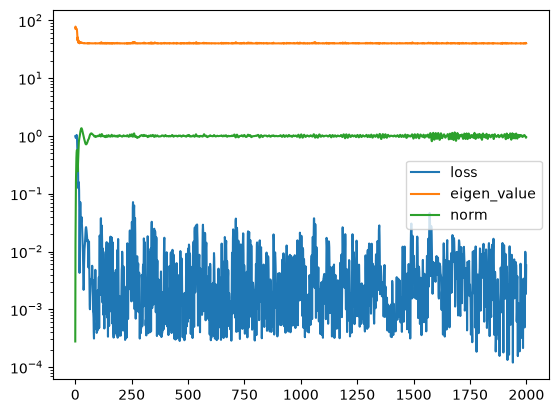

In [99]:
plt.plot(loss_true,label='loss')
plt.plot(eigen_value,label='eigen_value')
plt.plot(history.history['I'],label= 'norm')
plt.yscale("log")
plt.legend()
plt.show()

In [100]:
#model=keras.models.clone_model(name)
#set_weights(get_weights())
n_points=1000
x=np.linspace(-2,2,n_train)
y_train = np.sqrt(2/1.0)*np.sin(np.pi*x/1.0)
y_NN=model.predict(x)
y_NN=np.reshape(y_NN,n_train)
factor=x-x**2
y=y_NN*factor

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


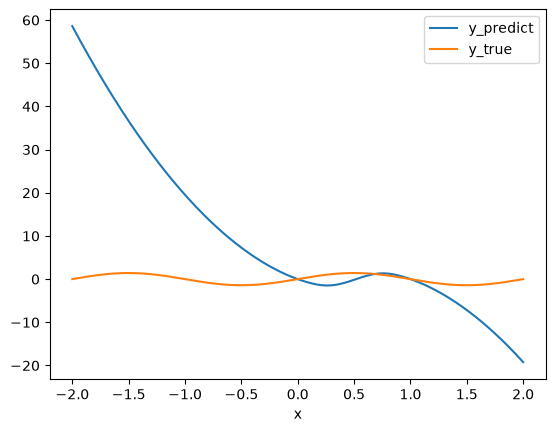

In [101]:
plt.plot(x,y,label='y_predict')
plt.plot(x,y_train,label='y_true')
plt.xlabel('x')
plt.legend()